# **Mercedes-Benz Greener Manufacturing**

## Workflow 1

### Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# # 1. Install uv in Colab
# !pip install -q uv

# # 2. Fast-install XGBoost into the Colab environment
# !uv pip install --system xgboost

from xgboost import XGBRegressor




RANDOM_STATE = 42

### Data Exploration

Loading Dataset

In [2]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

In [3]:
print(f"Train set shape: {train_df.shape}")
print(f"Test set shape : {test_df.shape}")
print()

Train set shape: (4209, 378)
Test set shape : (4209, 377)



In [4]:
print("\n--- Head (First 3 Rows) ---")
print(train_df.head(3))


--- Head (First 3 Rows) ---
   ID       y  X0 X1  X2 X3 X4 X5 X6 X8  ...  X375  X376  X377  X378  X379  \
0   0  130.81   k  v  at  a  d  u  j  o  ...     0     0     1     0     0   
1   6   88.53   k  t  av  e  d  y  l  o  ...     1     0     0     0     0   
2   7   76.26  az  w   n  c  d  x  j  x  ...     0     0     0     0     0   

   X380  X382  X383  X384  X385  
0     0     0     0     0     0  
1     0     0     0     0     0  
2     0     1     0     0     0  

[3 rows x 378 columns]


In [5]:
print(train_df.describe())
print()

                ID            y          X10     X11          X12  \
count  4209.000000  4209.000000  4209.000000  4209.0  4209.000000   
mean   4205.960798   100.669318     0.013305     0.0     0.075077   
std    2437.608688    12.679381     0.114590     0.0     0.263547   
min       0.000000    72.110000     0.000000     0.0     0.000000   
25%    2095.000000    90.820000     0.000000     0.0     0.000000   
50%    4220.000000    99.150000     0.000000     0.0     0.000000   
75%    6314.000000   109.010000     0.000000     0.0     0.000000   
max    8417.000000   265.320000     1.000000     0.0     1.000000   

               X13          X14          X15          X16          X17  ...  \
count  4209.000000  4209.000000  4209.000000  4209.000000  4209.000000  ...   
mean      0.057971     0.428130     0.000475     0.002613     0.007603  ...   
std       0.233716     0.494867     0.021796     0.051061     0.086872  ...   
min       0.000000     0.000000     0.000000     0.000000     

In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4209 entries, 0 to 4208
Columns: 378 entries, ID to X385
dtypes: float64(1), int64(369), str(8)
memory usage: 12.1 MB


#### Checking Missing, Duplicate

In [7]:
# Check for missing values
print("Missing values in train_df:", train_df.isna().sum().sum())
print("Missing values in test_df:", test_df.isna().sum().sum())

print("Duplicate rows in train_df:", train_df.duplicated().sum())
print("Duplicate IDs in train_df:", train_df["ID"].duplicated().sum())

Missing values in train_df: 0
Missing values in test_df: 0
Duplicate rows in train_df: 0
Duplicate IDs in train_df: 0


Output Column [check of outlier]

In [8]:
print(train_df["y"].describe())

count    4209.000000
mean      100.669318
std        12.679381
min        72.110000
25%        90.820000
50%        99.150000
75%       109.010000
max       265.320000
Name: y, dtype: float64


In [9]:
print(train_df["y"].sort_values(ascending=False).head(10))

883     265.32
342     169.91
1459    167.45
3133    165.52
1203    160.87
889     158.53
2735    158.23
3744    155.62
429     154.87
1060    154.43
Name: y, dtype: float64


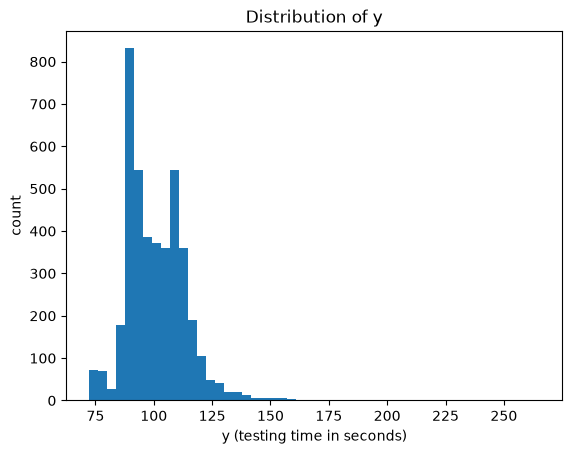

In [10]:
plt.hist(train_df["y"], bins=50)
plt.xlabel("y (testing time in seconds)")
plt.ylabel("count")
plt.title("Distribution of y")
plt.show()

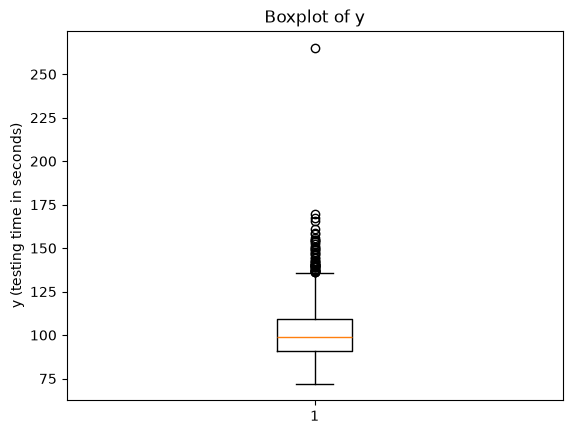

In [11]:
plt.boxplot(train_df["y"])
plt.ylabel("y (testing time in seconds)")
plt.title("Boxplot of y")
plt.show()

Checking Categorical features

In [12]:
categorical_cols = ["X0", "X1", "X2", "X3", "X4", "X5", "X6", "X8"]

for col in categorical_cols:
    print(col, train_df[col].nunique())

X0 47
X1 27
X2 44
X3 7
X4 4
X5 29
X6 12
X8 25


In [13]:
numeric_cols = []
for col in train_df.columns:
    if col != "ID" and col != "y" and col not in categorical_cols:
        numeric_cols.append(col)

print("number of numeric columns:", len(numeric_cols))

constant_cols = []
for col in numeric_cols:
    if train_df[col].nunique() == 1:
        constant_cols.append(col)

print("number of constant columns found:", len(constant_cols))
print(constant_cols)

number of numeric columns: 368
number of constant columns found: 12
['X11', 'X93', 'X107', 'X233', 'X235', 'X268', 'X289', 'X290', 'X293', 'X297', 'X330', 'X347']


In [14]:
for col in constant_cols:
    print(col, "unique values in test_df:", test_df[col].nunique())

X11 unique values in test_df: 2
X93 unique values in test_df: 2
X107 unique values in test_df: 2
X233 unique values in test_df: 2
X235 unique values in test_df: 2
X268 unique values in test_df: 2
X289 unique values in test_df: 2
X290 unique values in test_df: 2
X293 unique values in test_df: 2
X297 unique values in test_df: 2
X330 unique values in test_df: 2
X347 unique values in test_df: 2


In [15]:
for col in categorical_cols:
    print(col)
    print(train_df[col].value_counts())
    print()

X0
X0
z     360
ak    349
y     324
ay    313
t     306
x     300
o     269
f     227
n     195
w     182
j     181
az    175
aj    151
s     106
ap    103
h      75
d      73
al     67
v      36
af     35
ai     34
m      34
e      32
ba     27
at     25
a      21
ax     19
am     18
aq     18
i      18
u      17
l      16
aw     16
ad     14
k      11
b      11
au     11
as     10
r      10
bc      6
ao      4
c       3
q       2
aa      2
ac      1
g       1
ab      1
Name: count, dtype: int64

X1
X1
aa    833
s     598
b     592
l     590
v     408
r     251
i     203
a     143
c     121
o      82
w      52
z      46
u      37
e      33
m      32
t      31
h      29
y      23
f      23
j      22
n      19
k      17
p       9
g       6
d       3
q       3
ab      3
Name: count, dtype: int64

X2
X2
as    1659
ae     496
ai     415
m      367
ak     265
r      153
n      137
s       94
f       87
e       81
aq      63
ay      54
a       47
t       29
k       25
i       25
b       21
a

Drop contant columns, outlier row

1.   List item
2.   List item



In [16]:
train_df = train_df[train_df["y"] < 200].copy()
train_df = train_df.drop(columns=constant_cols)
test_df = test_df.drop(columns=constant_cols)

print("train_df shape after cleaning:", train_df.shape)

train_df shape after cleaning: (4208, 366)


Splitting into Train, Test Data

In [17]:
X = train_df.drop(columns=["ID", "y"])
y = train_df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

In [18]:

feature_cols = list(X_train.columns)
numeric_cols_final = [col for col in feature_cols if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("scale", StandardScaler(), numeric_cols_final),
])


# The 5 models we're comparing
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(random_state=42),
}

# Baseline: always predict the training mean
baseline_pred = np.full_like(y_test.values, y_train.mean(), dtype=float)
print("Baseline      RMSE:", round(root_mean_squared_error(y_test, baseline_pred), 4),
      "  R2:", round(r2_score(y_test, baseline_pred), 4))
print()

# hyperparameter grid per model
param_grids = {
    "Linear Regression": {
        "model__fit_intercept": [True, False],
    },
    "Decision Tree": {
        "model__max_depth": [5, 10, 20, None],       # how deep the tree can grow
        "model__min_samples_leaf": [1, 5, 10],       # min rows allowed in a leaf
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],      # how many trees to average
        "model__max_depth": [None, 10, 20],          # how deep each tree can grow
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 10, 15],        # how many neighbors vote
        "model__weights": ["uniform", "distance"],   # equal vote, or closer = louder vote
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 300],      # how many boosting rounds
        "model__max_depth": [3, 5, 7],               # how deep each individual tree can grow
        "model__learning_rate": [0.01, 0.1, 0.2],    # how much each round corrects the last one
    },
}

# KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

best_models = {}  # keep every fitted GridSearchCV object, in case we want the best one later

print(preprocessor)

# Tune + cross-validate every model
for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model),
    ])

    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=cv,
        scoring="r2",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    best_models[name] = grid

    test_r2 = grid.score(X_test, y_test)
    print(f"{name:20s} best CV R2: {round(grid.best_score_, 4):>7}   test R2: {round(test_r2, 4):>7}")
    print(f"{'':20s} best params: {grid.best_params_}")
    print()

Baseline      RMSE: 12.5298   R2: -0.0005

ColumnTransformer(transformers=[('onehot',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6',
                                  'X8']),
                                ('scale', StandardScaler(),
                                 ['X10', 'X12', 'X13', 'X14', 'X15', 'X16',
                                  'X17', 'X18', 'X19', 'X20', 'X21', 'X22',
                                  'X23', 'X24', 'X26', 'X27', 'X28', 'X29',
                                  'X30', 'X31', 'X32', 'X33', 'X34', 'X35',
                                  'X36', 'X37', 'X38', 'X39', 'X40', 'X41', ...])])
Linear Regression    best CV R2:  0.5513   test R2:  0.5128
                     best params: {'model__fit_intercept': True}

Decision Tree        best CV R2:  0.5929   test R2:  0.5566
                     best params: {'model__max_depth': 5, 'model__min_samples_leaf': 5}



## Workflow 2: Feature Engineering and Label Encoding

So far the categorical columns (`X0`, `X1`, ...) were handled with one-hot encoding. Now we add a simple engineered feature and switch the categorical encoding to **label encoding**, then compare the XGBoost result against the one-hot version above.

### Feature Engineering

Most of the remaining numeric columns are binary flags (0/1). We add one engineered feature, `binary_sum`, counting how many of those binary flags are switched on for each car configuration. This summarizes the "complexity" of a configuration in a single number.

In [19]:
binary_cols = [col for col in numeric_cols_final if X_train[col].nunique() <= 2]
print("Number of binary feature columns:", len(binary_cols))

X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe["binary_sum"] = X_train_fe[binary_cols].sum(axis=1)
X_test_fe["binary_sum"] = X_test_fe[binary_cols].sum(axis=1)

X_train_fe[["binary_sum"]].describe()

Number of binary feature columns: 356


,binary_sum
count,3366.000000
mean,58.076352
std,7.723324
min,31.000000
25%,53.000000
50%,58.000000
75%,63.000000
max,87.000000


### Label Encoding

Instead of one-hot encoding, we map each category to an integer with `LabelEncoder`, fit on the training data. Any category seen only in the test set is mapped to an explicit `"unseen"` code rather than crashing the encoder.

In [20]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train_fe[col] = le.fit_transform(X_train_fe[col])

    known = set(le.classes_)
    le.classes_ = np.append(le.classes_, "unseen")
    X_test_fe[col] = X_test_fe[col].where(X_test_fe[col].isin(known), "unseen")
    X_test_fe[col] = le.transform(X_test_fe[col])

    encoders[col] = le

X_train_fe[categorical_cols].head()

,X0,X1,X2,X3,X4,X5,X6,X8
3830,35,13,3,5,3,25,0,1
152,31,1,26,3,3,13,8,4
1557,19,10,16,2,3,3,11,10
2358,18,23,8,5,3,18,6,5
1316,36,22,40,2,3,2,4,5


### Train XGBoost with Label Encoding

All columns are numeric now, so the preprocessing step is a single `StandardScaler` over every feature (including the label-encoded categoricals and the new `binary_sum`). We tune XGBoost with the same hyperparameter grid and cross-validation setup used above, for a fair comparison.

In [21]:
feature_cols_fe = list(X_train_fe.columns)

preprocessor_le = ColumnTransformer([
    ("scale", StandardScaler(), feature_cols_fe),
])

pipe_le = Pipeline([
    ("prep", preprocessor_le),
    ("model", XGBRegressor(random_state=RANDOM_STATE)),
])

grid_le = GridSearchCV(
    pipe_le,
    param_grids["XGBoost"],
    cv=cv,
    scoring="r2",
    n_jobs=-1,
)
grid_le.fit(X_train_fe, y_train)

test_r2_le = grid_le.score(X_test_fe, y_test)
print("XGBoost (label encoding) best CV R2:", round(grid_le.best_score_, 4),
      "  test R2:", round(test_r2_le, 4))
print("best params:", grid_le.best_params_)

XGBoost (label encoding) best CV R2: 0.5975   test R2: 0.5729
best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300}


### Compare: One-Hot Encoding vs. Label Encoding + Feature Engineering

In [22]:
onehot_xgb = best_models["XGBoost"]
onehot_test_r2 = onehot_xgb.score(X_test, y_test)

comparison = pd.DataFrame({
    "CV R2": [onehot_xgb.best_score_, grid_le.best_score_],
    "Test R2": [onehot_test_r2, test_r2_le],
}, index=["XGBoost (one-hot)", "XGBoost (label encoding + FE)"])

comparison

,CV R2,Test R2
XGBoost (one-hot),0.598632,0.565107
XGBoost (label encoding + FE),0.597492,0.572913


Label encoding turns each category into a single ordered-looking integer column instead of many sparse one-hot columns. For tree-based models like XGBoost, which split on thresholds rather than assuming a linear relationship, this more compact representation can match or beat one-hot encoding while keeping the feature space much smaller. The comparison above shows whether that held true here, alongside the small boost (if any) from the `binary_sum` engineered feature.

## Error Analysis

We use the label-encoded XGBoost model (`grid_le`), our best test R2 so far, and look at where it goes wrong. We compute the absolute error for every row in the test set, sort by the largest misses, and inspect the top offenders alongside their original feature values.

In [23]:
y_pred_le = grid_le.predict(X_test_fe)
abs_error = np.abs(y_test.values - y_pred_le)

print("Mean absolute error:  ", round(abs_error.mean(), 3))
print("Median absolute error:", round(np.median(abs_error), 3))
print("Max absolute error:   ", round(abs_error.max(), 3))

Mean absolute error:   5.42
Median absolute error: 3.973
Max absolute error:    58.016


In [24]:
error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["y_pred"] = y_pred_le
error_df["abs_error"] = abs_error
error_df = error_df.sort_values("abs_error", ascending=False)

top_offenders = error_df.head(15)
top_offenders[["y_true", "y_pred", "abs_error"] + categorical_cols]

,y_true,y_pred,abs_error,X0,X1,X2,X3,X4,X5,X6,X8
1269,152.32,94.303642,58.016358,s,aa,m,c,d,ab,g,g
889,158.53,103.113266,55.416734,aj,l,as,f,d,ag,k,e
429,154.87,112.451797,42.418203,ak,l,ae,f,d,d,g,w
1427,135.29,94.303642,40.986358,s,aa,as,c,d,ac,j,v
1205,150.89,112.040733,38.849267,x,b,m,c,d,ab,j,j
1908,132.61,94.303642,38.306358,s,aa,m,c,d,ah,j,g
1551,132.60,94.487518,38.112482,o,s,ae,g,d,ad,g,j
2697,130.60,94.303642,36.296358,s,b,ai,a,d,m,j,s
6,128.76,94.106712,34.653288,al,r,e,f,d,f,h,s
2481,128.87,94.487518,34.382482,z,r,ai,f,d,n,j,t


### What to look for

A few things worth checking in the table above:

- Do the worst rows cluster around a particular category value in `X0`-`X8`, suggesting the model underfits a rare or unusual configuration?
- Is the model systematically over- or under-predicting (`y_pred` consistently higher or lower than `y_true`) for these rows, rather than erring in both directions?
- Do these rows have an unusually high or low `binary_sum`, hinting that very simple or very complex configurations are harder to predict?

In [25]:
over_under = np.where(top_offenders["y_pred"] > top_offenders["y_true"], "over-predicted", "under-predicted")
top_offenders["direction"] = over_under
top_offenders["binary_sum"] = X_test_fe.loc[top_offenders.index, "binary_sum"]

print(top_offenders["direction"].value_counts())
print()
top_offenders[["y_true", "y_pred", "abs_error", "direction", "binary_sum"]]

direction
under-predicted    15
Name: count, dtype: int64



,y_true,y_pred,abs_error,direction,binary_sum
1269,152.32,94.303642,58.016358,under-predicted,50
889,158.53,103.113266,55.416734,under-predicted,62
429,154.87,112.451797,42.418203,under-predicted,54
1427,135.29,94.303642,40.986358,under-predicted,60
1205,150.89,112.040733,38.849267,under-predicted,57
1908,132.61,94.303642,38.306358,under-predicted,50
1551,132.60,94.487518,38.112482,under-predicted,58
2697,130.60,94.303642,36.296358,under-predicted,53
6,128.76,94.106712,34.653288,under-predicted,53
2481,128.87,94.487518,34.382482,under-predicted,48


### Residual Plot

Residual = true minus predicted, for the full test set. Checks whether errors are random around zero or show a systematic pattern across the prediction range.

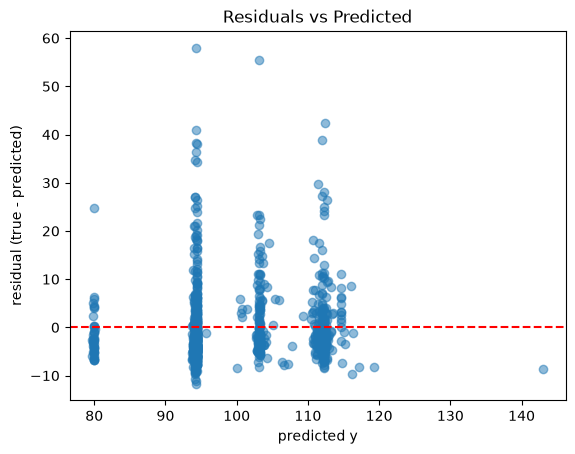

In [26]:
residual = y_test.values - y_pred_le

plt.scatter(y_pred_le, residual, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("predicted y")
plt.ylabel("residual (true - predicted)")
plt.title("Residuals vs Predicted")
plt.show()

### Error by Target Range

Bin `y_true` into ranges and compute mean absolute error per bin. Checks whether high-`y` rows are harder to predict across the whole test set, not just the top 15 offenders.

In [27]:
bins = [0, 90, 100, 110, 130, 300]
y_bin = pd.cut(y_test, bins=bins)

error_by_bin = pd.DataFrame({"y_true": y_test.values, "abs_error": abs_error, "y_bin": y_bin.values})
error_by_bin.groupby("y_bin")["abs_error"].agg(["mean", "count"])

,mean,count
y_bin,,
"(0, 90]",5.563137,179
"(90, 100]",2.818839,266
"(100, 110]",4.633485,214
"(110, 130]",7.696844,167
"(130, 300]",33.796661,16


### Finding

Mean abs error stays under 8 for `y_true` up to 130, then jumps to 33.8 for `y_true > 130` (16 rows, 0.4% of the test set). The model's error isn't spread evenly across the target range. it happens mostly in the high `y` values.

## Predict on the Competition Test Set

`test_df` has no `y` column — it is the unlabeled Kaggle test set. We apply the same label encoding and `binary_sum` feature used on train, predict with `grid_le`, and write a submission file.

In [28]:
submit_df = test_df.drop(columns=["ID"]).copy()

for col in categorical_cols:
    le = encoders[col]
    known = set(le.classes_) - {"unseen"}
    submit_df[col] = submit_df[col].where(submit_df[col].isin(known), "unseen")
    submit_df[col] = le.transform(submit_df[col])

submit_df["binary_sum"] = submit_df[binary_cols].sum(axis=1)

submit_pred = grid_le.predict(submit_df)
submit_pred[:5]

array([ 79.70743,  93.80768,  79.53588,  79.70743, 110.6415 ],
      dtype=float32)

In [29]:
submission = pd.DataFrame({"ID": test_df["ID"], "y": submit_pred})
submission.to_csv("data/submission.csv", index=False)
submission.head()

,ID,y
0,1,79.707428
1,2,93.807678
2,3,79.535881
3,4,79.707428
4,5,110.641502


## Serialize the Model

Save the tuned pipeline (`grid_le.best_estimator_`) so it can be reloaded for prediction without rerunning the grid search.

In [30]:
import joblib

bundle = {
    "pipeline": grid_le.best_estimator_,
    "encoders": encoders,
    "categorical_cols": categorical_cols,
    "constant_cols": constant_cols,
    "binary_cols": binary_cols,
    "feature_cols": feature_cols_fe,
    "model_version": "xgb_label_encoded_v1",
}
joblib.dump(bundle, "models/mercedes_pipeline_bundle.pkl")

['models/mercedes_pipeline_bundle.pkl']